<a href="https://colab.research.google.com/github/rodrigourech/gdv/blob/main/Revision_Newplots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ------------------------------
# Data Import & Preparation
# ------------------------------
import pandas as pd
import matplotlib.pyplot as plt

# Quellen (GitHub Repository: MeteoSchweiz CH2018 Szenarien)
url_rcp45 = "https://raw.githubusercontent.com/rodrigourech/ivi/main/data/RCP45_tas.csv"
url_rcp85 = "https://raw.githubusercontent.com/rodrigourech/ivi/main/data/RCP85_tas.csv"

# CSVs einlesen
# Best Practices (EEA, 2023): UTF-8 Encoding, parse_dates für Zeitspalten
df_rcp45 = pd.read_csv(url_rcp45, parse_dates=["date"], encoding="utf-8-sig")
df_rcp85 = pd.read_csv(url_rcp85, parse_dates=["date"], encoding="utf-8-sig")

# Subsets für Performance-Tests (kleines vs. grosses Sample)
df_rcp45_small = df_rcp45.sample(n=3000, random_state=42).reset_index(drop=True)
df_rcp85_large = df_rcp85.sample(n=300000, random_state=42).reset_index(drop=True)

# Szenario-Label hinzufügen
df_rcp45_small["scenario"] = "RCP4.5"
df_rcp85_large["scenario"] = "RCP8.5"

# Zusammenführen
df = pd.concat([df_rcp45_small, df_rcp85_large], ignore_index=True)

# Jahr extrahieren
df["year"] = df["date"].dt.year

# ------------------------------
# Aggregation: Jahresmittel
# ------------------------------
df_yearly = df.groupby(["year", "scenario"]).agg({"value": "mean"}).reset_index()

# ------------------------------



In [4]:
# ============================================
# Decadal Mean Temperature – Vorbereitung
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Falls noch nicht vorhanden:
df["year"] = df["date"].dt.year
df["decade"] = (df["year"] // 10) * 10

# --- Parameter ---
SELECT_SCENARIO = "RCP8.5"     # oder "RCP4.5"
stations_order  = ["Zürich", "Lugano", "Davos"]  # ggf. an deine Stationsnamen anpassen

# --- Aggregation: Dekadenmittel pro Station (innerhalb eines Szenarios) ---
decadal = (
    df[df["scenario"] == SELECT_SCENARIO]
    .groupby(["decade", "station"], as_index=False)["value"]
    .mean()
)

# Nur die gewünschten Stationen & sortieren
decadal = decadal[decadal["station"].isin(stations_order)]
decades = sorted(decadal["decade"].unique())


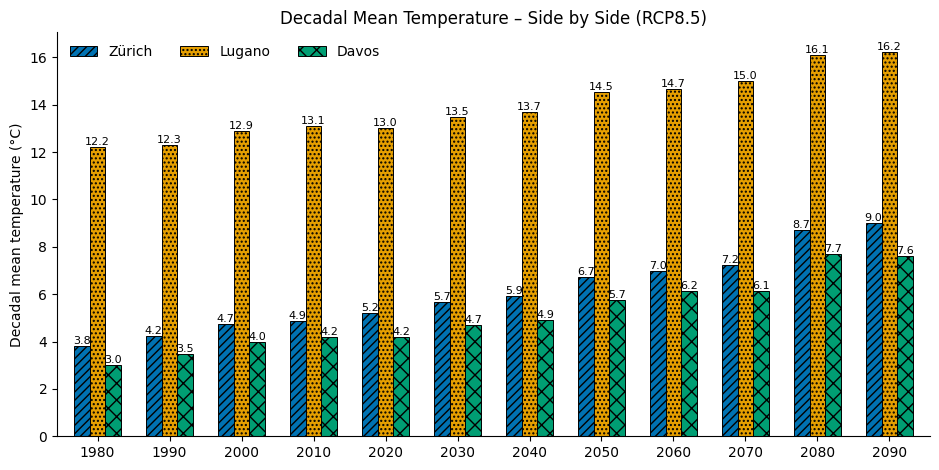

In [6]:
# =========================================================
# Figure 4 — Side by Side (colour-blind safe + Schraffuren)
# =========================================================

# Okabe–Ito (Colour-blind safe)
okabe_ito = {
    "Zürich": "#0072B2",  # blue
    "Lugano": "#E69F00",  # orange
    "Davos":  "#009E73",  # green
}

# Redundante Kodierung via Schraffuren (falls Graustufen)
hatches = {
    "Zürich": "////",
    "Lugano": "....",
    "Davos":  "xx",
}

bar_w = 0.22
x = np.arange(len(decades))

fig, ax = plt.subplots(figsize=(9.5, 4.8))

for i, st in enumerate(stations_order):
    sub = (
        decadal[decadal["station"] == st]
        .set_index("decade")
        .reindex(decades)  # fehlende Dekaden -> NaN
    )
    y = sub["value"].to_numpy()

    ax.bar(
        x + (i - 1)*bar_w, y, width=bar_w,
        color=okabe_ito.get(st, "#999999"),
        edgecolor="black", linewidth=0.7,
        hatch=hatches.get(st, ""),
        label=st
    )

    # Werte-Labels (optional, robust gegen NaN)
    for xi, yi in zip(x + (i - 1)*bar_w, y):
        if pd.notna(yi):
            ax.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in decades])
ax.set_ylabel("Decadal mean temperature (°C)")
ax.set_title(f"Decadal Mean Temperature – Side by Side ({SELECT_SCENARIO})")
ax.legend(ncol=len(stations_order), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.02)
plt.tight_layout()
plt.show()


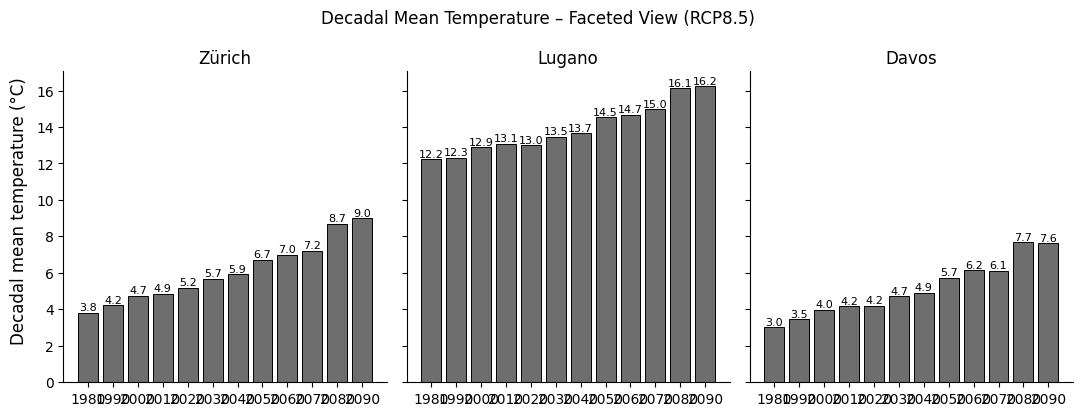

In [7]:
# ==============================================
# Figure 5 — Faceted View (Monochrom, sharey)
# ==============================================
cols = len(stations_order)
fig, axes = plt.subplots(1, cols, figsize=(11, 4.2), sharey=True)

for ax, st in zip(axes, stations_order):
    sub = (
        decadal[decadal["station"] == st]
        .sort_values("decade")
    )

    ax.bar(
        sub["decade"].astype(str), sub["value"],
        color="#6e6e6e", edgecolor="black", linewidth=0.7
    )

    # Dezente Labels (optional)
    for xi, yi in zip(sub["decade"].astype(str), sub["value"]):
        if pd.notna(yi):
            ax.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(st)
    ax.spines[["top", "right"]].set_visible(False)

fig.supylabel("Decadal mean temperature (°C)")
fig.suptitle(f"Decadal Mean Temperature – Faceted View ({SELECT_SCENARIO})")
plt.tight_layout()
plt.show()
